# Statistics Practical: Student Performance

A short exercise in descriptive statistics, correlation and linear regression.


## my goal

Summarise a small dataset, explore relationships and make a simple prediction.


## 1. imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

students = pd.DataFrame({
    "Student": [1, 2, 3, 4, 5, 6],
    "Study Hours": [5, 8, 10, 12, 15, 18],
    "Attendance": [60, 75, 80, 85, 90, 95],
    "Assignment": [45, 58, 62, 70, 82, 90],
    "Exam Score": [48, 60, 67, 74, 85, 92]
})
sns.set_theme(style="whitegrid")
students

,Student,Study Hours,Attendance,Assignment,Exam Score
0,1,5,60,45,48
1,2,8,75,58,60
2,3,10,80,62,67
3,4,12,85,70,74
4,5,15,90,82,85
5,6,18,95,90,92


## 2. Descriptive statistics


In [2]:
students.drop(columns="Student").agg(["mean", "median", "std", "min", "max"]).round(2)

,Study Hours,Attendance,Assignment,Exam Score
mean,11.33,80.83,67.83,71.0
median,11.00,82.50,66.00,70.5
std,4.72,12.42,16.42,16.2
min,5.00,60.00,45.00,48.0
max,18.00,95.00,90.00,92.0


The mean describes the centre of the data. Standard deviation describes how spread out the values are.


## 3. Visualise the relationship


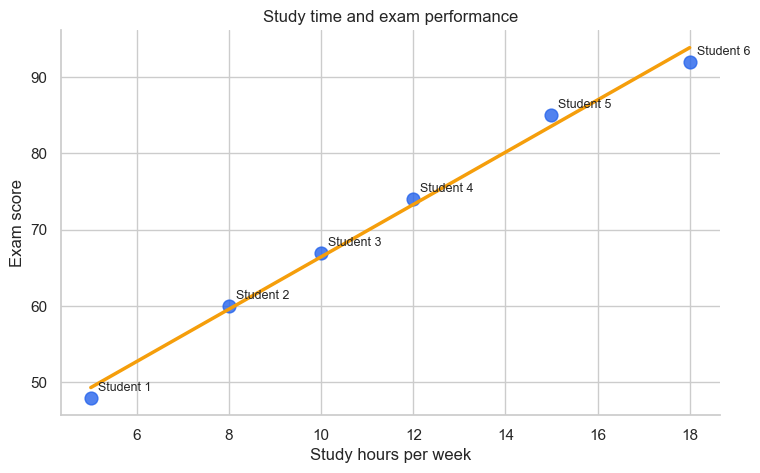

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.regplot(data=students, x="Study Hours", y="Exam Score", ci=None,
            scatter_kws={"s": 85, "color": "#2563EB"},
            line_kws={"color": "#F59E0B", "linewidth": 2.5}, ax=ax)
for _, row in students.iterrows():
    ax.annotate(f"Student {int(row['Student'])}", (row["Study Hours"], row["Exam Score"]), xytext=(5, 5),
                textcoords="offset points", fontsize=9)
ax.set(title="Study time and exam performance", xlabel="Study hours per week", ylabel="Exam score")
sns.despine()
plt.show()

## 4. Correlation

Correlation ranges from -1 to 1 and measures the strength of a linear relationship.


In [4]:
correlations = (students.drop(columns="Student")
                .corr()[["Exam Score"]]
                .drop(index="Exam Score")
                .sort_values("Exam Score", ascending=False))
correlations.round(3)

,Exam Score
Assignment,0.998
Study Hours,0.997
Attendance,0.979


Correlation does not prove that one variable causes another.


## 5. Fit a linear regression


In [5]:
slope, intercept = np.polyfit(students["Study Hours"], students["Exam Score"], 1)
students["Predicted Score"] = intercept + slope * students["Study Hours"]
rmse = np.sqrt(np.mean((students["Exam Score"] - students["Predicted Score"]) ** 2))

print(f"Model: Exam Score = {intercept:.2f} + {slope:.2f} × Study Hours")
print(f"RMSE: {rmse:.2f} marks")

Model: Exam Score = 32.22 + 3.42 × Study Hours
RMSE: 1.17 marks


## 6. Make a prediction


In [6]:
new_study_hours = 13
predicted_score = intercept + slope * new_study_hours
print(f"Predicted score for {new_study_hours} study hours: {predicted_score:.1f}")

Predicted score for 13 study hours: 76.7


## 7. Identify students who may need support


In [7]:
students["Risk Score"] = (
    (students["Study Hours"] < 9).astype(int)
    + (students["Attendance"] < 75).astype(int)
    + (students["Assignment"] < 56).astype(int)
    + (students["Predicted Score"] < 60).astype(int)
)
students.loc[students["Risk Score"] >= 2,
             ["Student", "Study Hours", "Attendance", "Exam Score", "Risk Score"]]

,Student,Study Hours,Attendance,Exam Score,Risk Score
0,1,5,60,48,4
1,2,8,75,60,2


## My highlights and takeaways

- Study hours, attendance and assignment marks all have strong positive relationships with exam scores in this small sample.
- The regression gives a useful estimate, but six students are not enough for a general conclusion.
- A risk score can guide support, but it should not replace human judgement.
